In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 18


Część 1

In [ ]:
# -----------------------------------------------------------------------------
#1.1
# -----------------------------------------------------------------------------
wine=sklearn.datasets.load_wine()
X=wine.data
Y=wine.target
nazwy_cech=wine.feature_names
nazwy_gatunkow=wine.target_names
# -----------------------------------------------------------------------------
1.2
# -----------------------------------------------------------------------------
print(f"\nWymiary danych: {X.shape[0]} próbek × {X.shape[1]} cechy")
print(f"Cechy: {nazwy_cech}")
print(f"Gatunki: {nazwy_gatunkow}")


Wymiary danych: 178 próbek × 13 cechy
Cechy: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Gatunki: ['class_0' 'class_1' 'class_2']


In [ ]:
# -----------------------------------------------------------------------------
1.3
# -----------------------------------------------------------------------------
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print("--- ŚREDNIA (Oczekiwana: 0) ---")
print(f"Przed: {X.mean(axis=0).round(2)}")
print(f"Po:    {X_std.mean(axis=0).round(2)}")

print("\n--- ODCHYLENIE STANDARDOWE (Oczekiwane: 1) ---")
print(f"Przed: {X.std(axis=0).round(2)}")
print(f"Po:    {X_std.std(axis=0).round(2)}")

#PCA jest algorytmem wrażliwym na skalę danych. Bez standaryzacji wyniki analizy będą zafałszowane i mylące.

--- ŚREDNIA (Oczekiwana: 0) ---
Przed: [1.3000e+01 2.3400e+00 2.3700e+00 1.9490e+01 9.9740e+01 2.3000e+00
 2.0300e+00 3.6000e-01 1.5900e+00 5.0600e+00 9.6000e-01 2.6100e+00
 7.4689e+02]
Po:    [ 0.  0. -0. -0. -0. -0.  0. -0. -0. -0.  0.  0. -0.]

--- ODCHYLENIE STANDARDOWE (Oczekiwane: 1) ---
Przed: [8.1000e-01 1.1100e+00 2.7000e-01 3.3300e+00 1.4240e+01 6.2000e-01
 1.0000e+00 1.2000e-01 5.7000e-01 2.3100e+00 2.3000e-01 7.1000e-01
 3.1402e+02]
Po:    [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Część 2

In [ ]:
#-------------------------------------------------------------------------------
2.1
#-------------------------------------------------------------------------------

pca = PCA()
X_pca = pca.fit_transform(X_std)

#-------------------------------------------------------------------------------
2.2
#-------------------------------------------------------------------------------

print("\nWartości własne (eigenvalues):")
for i, ev in enumerate(pca.explained_variance_):
    print(f"  PC{i+1}: {ev:.3f}")

print("\nWyjaśniona wariancja (%):")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var*100:.1f}%")

print(f"\nSkumulowana wariancja:")
cumsum = np.cumsum(pca.explained_variance_ratio_)
for i, cs in enumerate(cumsum):
    print(f"  PC1-PC{i+1}: {cs*100:.1f}%")

#-------------------------------------------------------------------------------
#2.3
#-------------------------------------------------------------------------------
d = np.argmax(cumsum >= 0.80) + 1
print(f"Liczba składowych potrzebna do wyjaśnienia 80% wariancji: {d}")



Wartości własne (eigenvalues):
  PC1: 4.732
  PC2: 2.511
  PC3: 1.454
  PC4: 0.924
  PC5: 0.858
  PC6: 0.645
  PC7: 0.554
  PC8: 0.350
  PC9: 0.291
  PC10: 0.252
  PC11: 0.227
  PC12: 0.170
  PC13: 0.104

Wyjaśniona wariancja (%):
  PC1: 36.2%
  PC2: 19.2%
  PC3: 11.1%
  PC4: 7.1%
  PC5: 6.6%
  PC6: 4.9%
  PC7: 4.2%
  PC8: 2.7%
  PC9: 2.2%
  PC10: 1.9%
  PC11: 1.7%
  PC12: 1.3%
  PC13: 0.8%

Skumulowana wariancja:
  PC1-PC1: 36.2%
  PC1-PC2: 55.4%
  PC1-PC3: 66.5%
  PC1-PC4: 73.6%
  PC1-PC5: 80.2%
  PC1-PC6: 85.1%
  PC1-PC7: 89.3%
  PC1-PC8: 92.0%
  PC1-PC9: 94.2%
  PC1-PC10: 96.2%
  PC1-PC11: 97.9%
  PC1-PC12: 99.2%
  PC1-PC13: 100.0%
Liczba składowych potrzebna do wyjaśnienia 80% wariancji: 5


Część 3

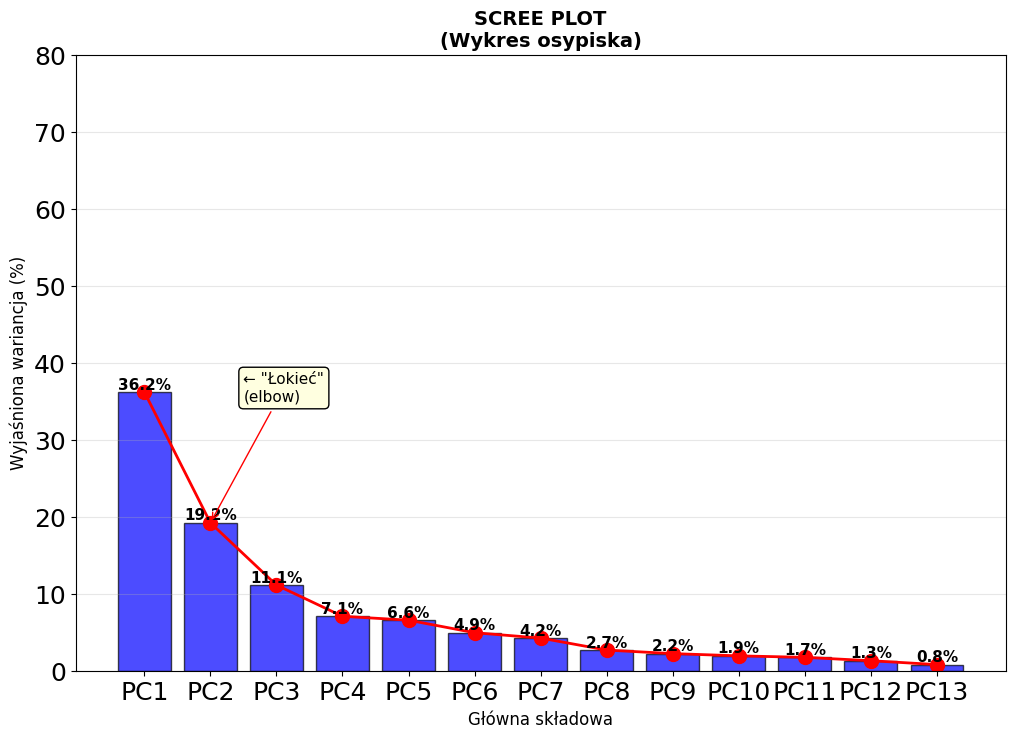

In [ ]:

#-------------------------------------------------------------------------------
3.1
#-------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 8))
ax1 = ax
pc_labels = ['PC1', 'PC2', 'PC3', 'PC4','PC5','PC6','PC7','PC8','PC9','PC10','PC11','PC12','PC13']
variance_pct = pca.explained_variance_ratio_ * 100

bars = ax1.bar(pc_labels, variance_pct, color='blue', edgecolor='black', alpha=0.7)
ax1.plot(pc_labels, variance_pct, 'ro-', markersize=10, linewidth=2)
ax1.set_ylabel('Wyjaśniona wariancja (%)', fontsize=12)
ax1.set_xlabel('Główna składowa', fontsize=12)
ax1.set_title('SCREE PLOT\n(Wykres osypiska)', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 80)

for bar, pct in zip(bars, variance_pct):
    ax1.annotate(f'{pct:.1f}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.annotate('← "Łokieć"\n(elbow)', xy=(1, variance_pct[1]), xytext=(1.5, 35),
             fontsize=11, arrowprops=dict(arrowstyle='->', color='red'),
             bbox=dict(boxstyle='round', facecolor='lightyellow'))
ax1.grid(axis='y', alpha=0.3)

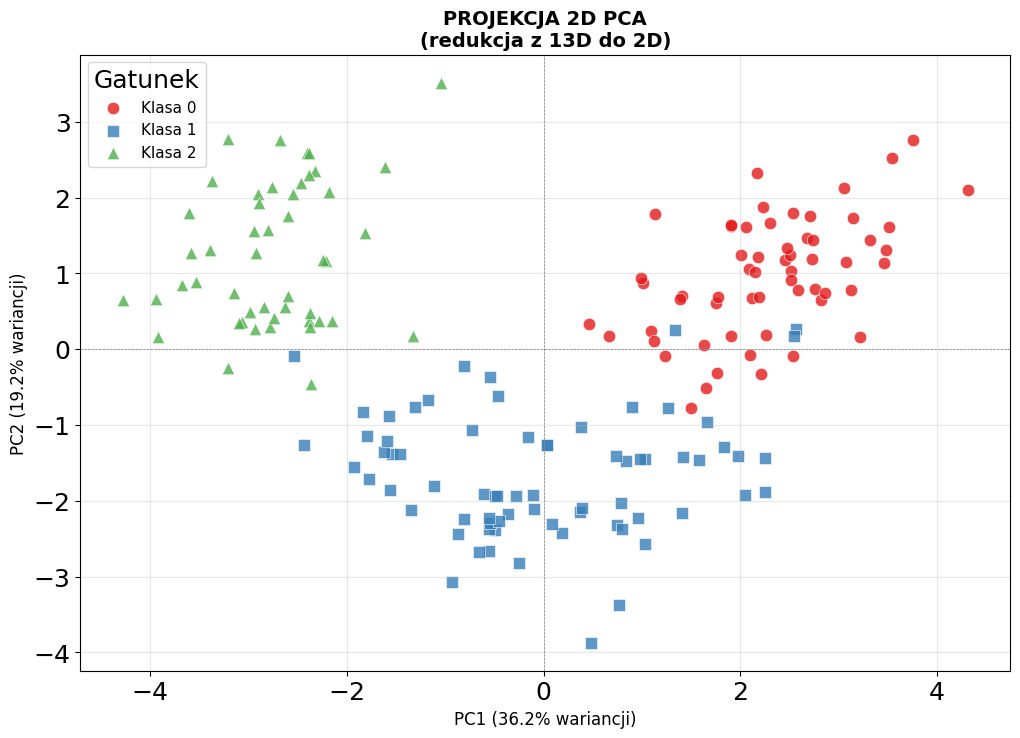

In [ ]:
#-------------------------------------------------------------------------------
3.2
#-------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e41a1c', '#377eb8', '#4daf4a']
markers = ['o', 's', '^']

for i, (gatunek, kolor, marker) in enumerate(zip(nazwy_gatunkow, colors, markers)):
    mask = y == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=kolor, marker=marker, s=80, label=gatunek,
               edgecolor='white', linewidth=0.5, alpha=0.8)

ax.set_xlabel(f'PC1 ({variance_pct[0]:.1f}% wariancji)', fontsize=12)
ax.set_ylabel(f'PC2 ({variance_pct[1]:.1f}% wariancji)', fontsize=12)
ax.set_title('PROJEKCJA 2D PCA\n(redukcja z 13D do 2D)', fontsize=14, fontweight='bold')

ax.legend(title='Gatunek', fontsize=11)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)
ax.grid(True, alpha=0.3)

plt.show()

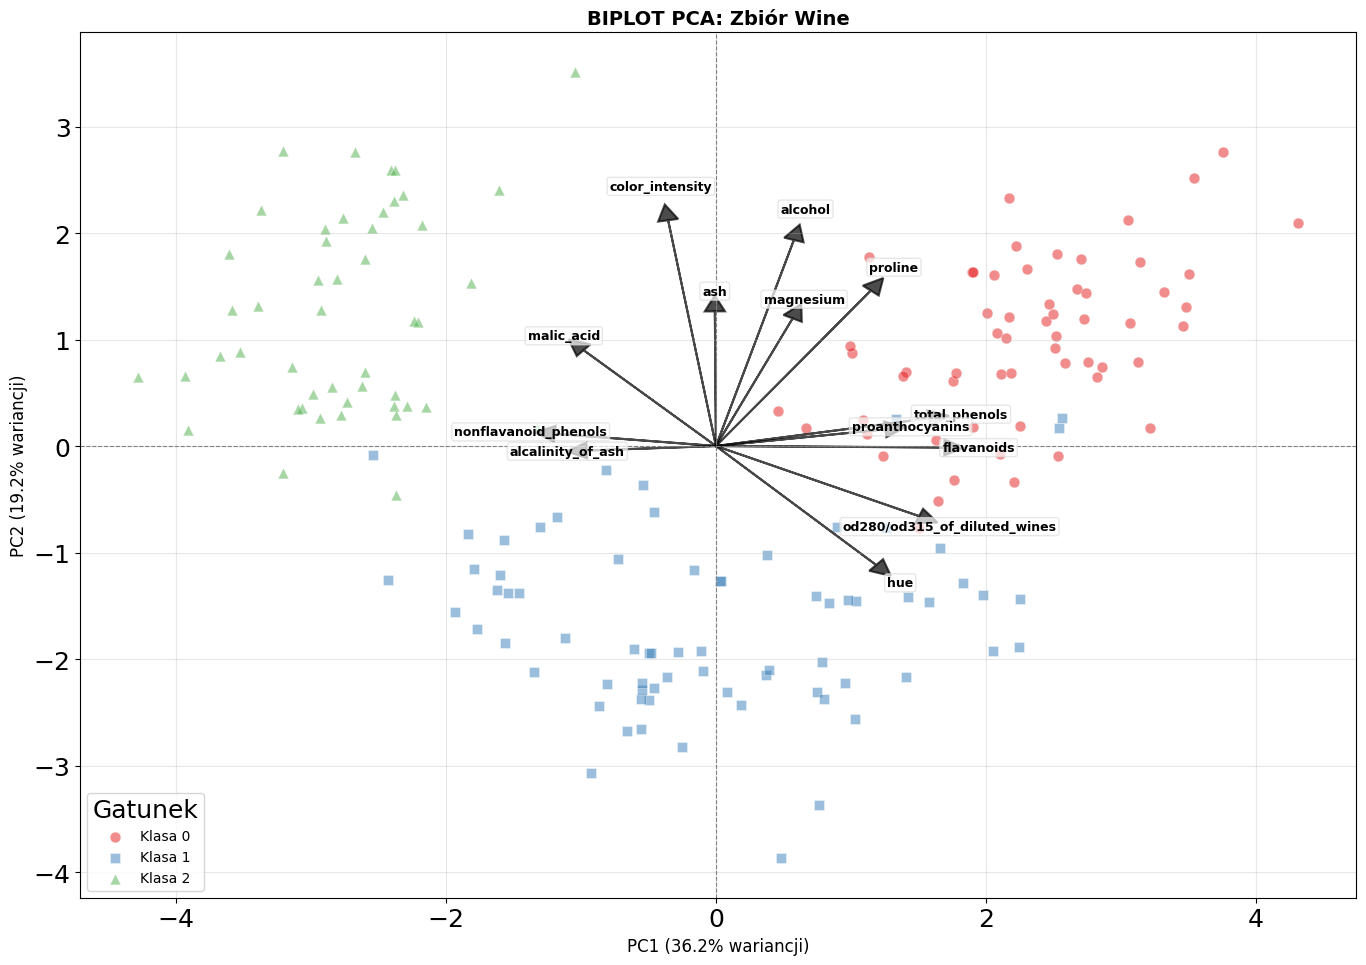

In [ ]:
# -------------------------------------------------------------------------------
# 3.3
# -------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 10))  # Większy rozmiar dla 13 wektorów

colors = ['#e41a1c', '#377eb8', '#4daf4a']
markers = ['o', 's', '^']

# 1. Rysowanie punktów danych
for i, (gatunek, kolor, marker) in enumerate(zip(nazwy_gatunkow, colors, markers)):
    mask = y == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=kolor, marker=marker, s=60, label=gatunek,
               edgecolor='white', linewidth=0.5, alpha=0.5)

# 2. Rysowanie wektorów cech
scale = 4

for i, nazwa in enumerate(nazwy_cech):
    x_vec = pca.components_[0, i] * scale
    y_vec = pca.components_[1, i] * scale

    ax.arrow(0, 0, x_vec, y_vec,
             head_width=0.15, head_length=0.15, fc='black', ec='black', linewidth=1.5, alpha=0.7)

    ax.text(x_vec * 1.15, y_vec * 1.15,
            nazwa, color='black', fontsize=9, fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='#dddddd'))

ax.set_xlabel(f'PC1 ({variance_pct[0]:.1f}% wariancji)', fontsize=12)
ax.set_ylabel(f'PC2 ({variance_pct[1]:.1f}% wariancji)', fontsize=12)
ax.set_title('BIPLOT PCA: Zbiór Wine', fontsize=14, fontweight='bold')
ax.legend(title='Gatunek', fontsize=10, loc='lower left')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Część 4

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

loadings_df = pd.DataFrame(
    pca.components_.T[:, :2],
    columns=['PC1', 'PC2'],
    index=nazwy_cech
)

print("Ładunki (Loadings) dla PC1 i PC2")
print(loadings_df.round(3))

Ładunki (Loadings) dla PC1 i PC2
                                PC1    PC2
alcohol                       0.144  0.484
malic_acid                   -0.245  0.225
ash                          -0.002  0.316
alcalinity_of_ash            -0.239 -0.011
magnesium                     0.142  0.300
total_phenols                 0.395  0.065
flavanoids                    0.423 -0.003
nonflavanoid_phenols         -0.299  0.029
proanthocyanins               0.313  0.039
color_intensity              -0.089  0.530
hue                           0.297 -0.279
od280/od315_of_diluted_wines  0.376 -0.164
proline                       0.287  0.365


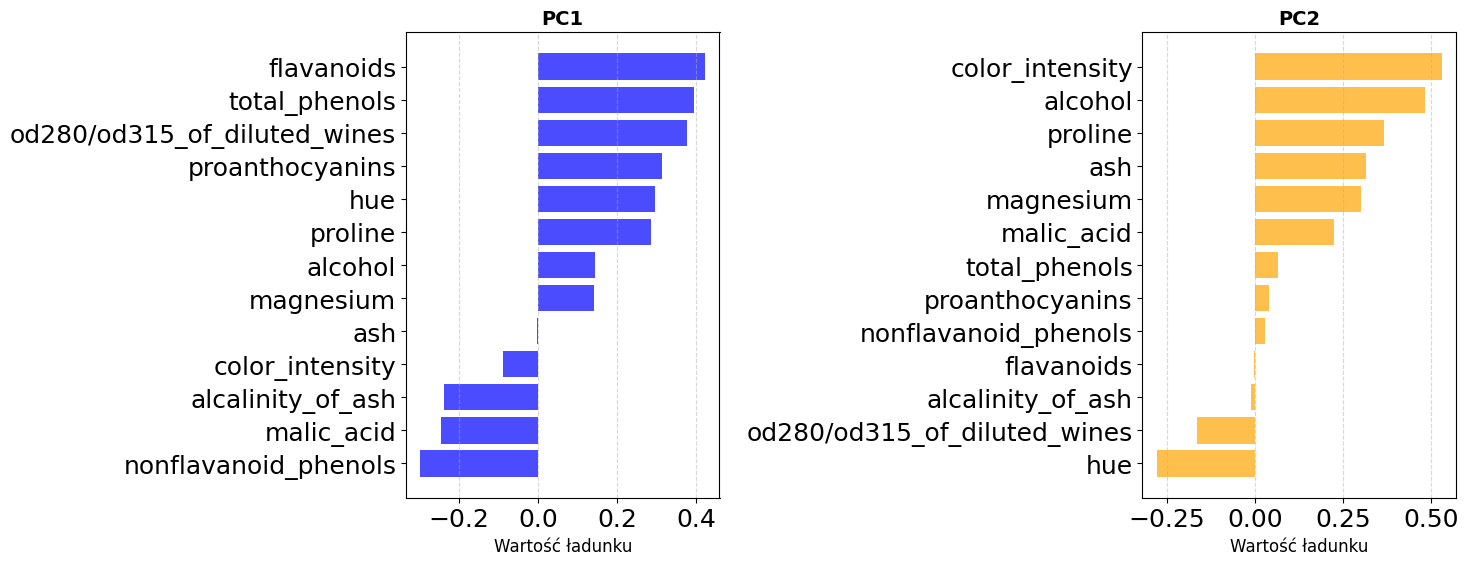

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Wykres dla PC1
pc1_sorted = loadings_df['PC1'].sort_values()

axes[0].barh(pc1_sorted.index, pc1_sorted.values, color='blue', alpha=0.7)
axes[0].set_title('PC1', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Wartość ładunku', fontsize=12)
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# Wykres dla PC2
pc2_sorted = loadings_df['PC2'].sort_values()

axes[1].barh(pc2_sorted.index, pc2_sorted.values, color='orange', alpha=0.7)
axes[1].set_title('PC2', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Wartość ładunku', fontsize=12)
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#1
Dominujące cechy dla PC1:
1.   Flavanoids
2.   Total phenols
3.   OD280/OD315 of diluted wines
4.   Proanthocyanins

Dodatkowo ujemną, aczkolwiek wysoką wartość przedstawia:


1.   Nonflavanoid Phenols

Składowa ta najsilniej rozpoznaje wina z bogate w Flavanoids.

#2
 Dominujące cechy dla PC2:
 1. Color intensity
 2. Alcohol
 3. Proline
 4. Ash

#3
Tak, klasy są bardzo dobrze separowalne.
Patrząc na wykres punktowy, widzimy trzy wyraźne grupy, które prawie na siebie nie nachodzą. Wyłąćznie klasa 1 lekko nachodzi na klasę 0 oraz klasę 2

Oznacza to, że zredukowanie do 2D pozostawiło najważniejsze elementy potrzebne do rozróznienia win